# CausalMix Generative Framework

This notebook demonstrates how to use **CausalMix** to generate and evaluate synthetic datasets that preserve both distributional realism and causal structure.

CausalMix instantiates a modular data-generating mechanism built on a conditional VAE backbone.

The observational distribution is factorized as:

p(X, T, Y) = p(T) p(X | T) p(Y | X, T)

and modeled using three components: **Treatment model** for T, **Pre-treatment generator** for p(X | T), and **Post-treatment generator** for potential outcomes (Y(0), Y(1)) | X, T, while preserving explicit control over treatment effects, overlap and unmeasured confounding.

The training process with modular generators have been demonstrated in `notebooks/examples/ConVAE_example.ipynb`.

## Structure
1. **Environment & Imports** – Load required libraries.
2. **Causal Dataset Simulation** – Simulate a toy dataset as the original dataset.
3. **CausalMix Model Training** – Train the full CausalMix model
4. **Synthetic Data Generation and Evaluation** – Evaluate distributional fidelity, causal structure and privacy (defined as record-level disclosure risk).

## **Environment & Imports** – Load required libraries.

In [0]:
# this script was used to show how to use the CausalMix class and the pipeline
# check GPU availability
import torch
import os

print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
print("numer of cores:",os.cpu_count())


CUDA available: True
GPU name: NVIDIA L40S
numer of cores: 8


In [0]:
from pyspark.sql import functions as sparkF
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [0]:
from causalmix import (
    CausalMix,
    conVAE,
    SynthEval,
    CausalEval,
    DataSchema,
    VarIndex,
    fit_metadata,
    preprocess_with_meta,
    postprocess_generated,
    build_table_distributional_fidelity,
    build_table_privacy,
    build_table_causal_structure,
    eval_tables_mean,
    single_column_plot,
    pair_column_plot,
    plot_joint_embedding_2d,
)

## Data Generating Process (DGP)

We simulate a binary treatment and binary outcome setting with mixed-type covariates.

For each unit i = 1, …, n:

### Covariates

X_i = (X_bin, X_cat, X_exp, X_uniform, X_beta)

- X_bin ~ Bernoulli(0.4)
- X_cat ∈ {A, B, C}
- X_exp ~ Exponential(1)
- X_uniform ~ Uniform(-3, 3)
- X_beta ~ Beta(2, 5)

Categorical variables are one-hot encoded to form the design vector X_design.

### Treatment

T_i ~ Bernoulli(0.5)

(Treatment is randomized; overlap can be modified by changing the assignment mechanism.)

### Potential Outcomes

logit P(Y_i(0) = 1 | X_i) = X_design · β  
logit P(Y_i(1) = 1 | X_i) = X_design · β + τ

where β is a fixed coefficient vector and τ = 0.5 is the treatment effect on the log-odds scale.

The observed outcome is:

Y_i = T_i * Y_i(1) + (1 − T_i) * Y_i(0)

This setup provides a simple but heterogeneous tabular dataset suitable for illustrating conVAE.

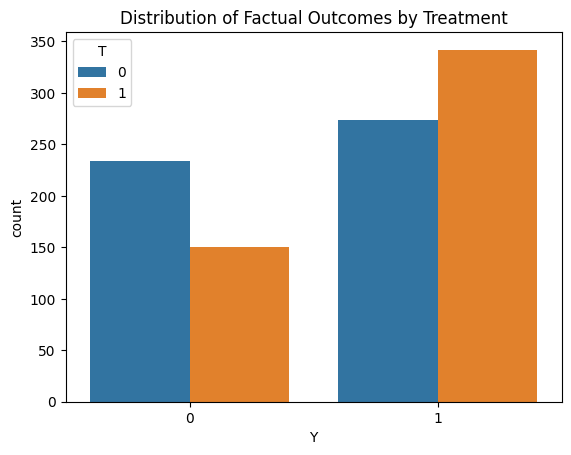

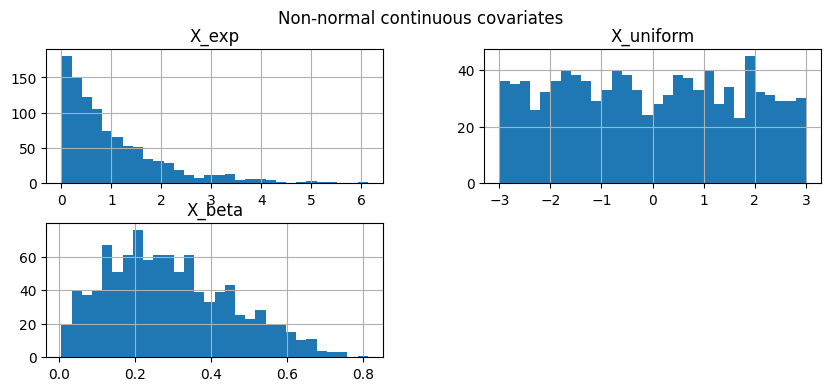

In [0]:
# simulate a toy causal dataset 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 1000

# -----------------------------
# Covariates
# -----------------------------
# Binary variable
X_bin = np.random.binomial(1, 0.4, size=n)

# Categorical variable (3 levels)
X_cat = np.random.choice(['A', 'B', 'C'], size=n, p=[0.3, 0.5, 0.2])

# Continuous non-normal variables
X_exp = np.random.exponential(scale=1.0, size=n)         # skewed right
X_uniform = np.random.uniform(-3, 3, size=n)             # flat distribution
X_beta = np.random.beta(a=2, b=5, size=n)                # bounded, skewed

# Stack into design matrix for potential outcome model
# For the categorical variable, we’ll one-hot encode when computing logits
X_cat_dummies = pd.get_dummies(X_cat, drop_first=True)  # B, C vs baseline A
X_design = np.column_stack([X_bin, X_exp, X_uniform, X_beta, X_cat_dummies.values])

# Build full covariate dataframe
X = pd.DataFrame({
    'X_bin': X_bin,
    'X_cat': X_cat,
    'X_exp': X_exp,
    'X_uniform': X_uniform,
    'X_beta': X_beta
})

# -----------------------------
# Treatment assignment
# -----------------------------
T = np.random.binomial(1, 0.5, size=n) # overlap can be controlled by modifying the treatment 

# -----------------------------
# Potential outcomes
# -----------------------------
# Coefficients: binary + 3 continuous + 2 dummies = 6 vars
coef = np.array([0.5, -0.3, 0.2, 0.4, 0.6, -0.2])

logit_Y0 = np.dot(X_design, coef)
prob_Y0 = 1 / (1 + np.exp(-logit_Y0))

logit_Y1 = logit_Y0 + 0.5  # treatment effect can vary dependening on covariates by modifying here
prob_Y1 = 1 / (1 + np.exp(-logit_Y1))

Y0 = np.random.binomial(1, prob_Y0)
Y1 = np.random.binomial(1, prob_Y1)
Y = Y1 * T + Y0 * (1 - T)

# -----------------------------
# Build dataframe
# -----------------------------
df = pd.DataFrame({
    'X_bin': X_bin,
    'X_cat': X_cat,
    'X_exp': X_exp,
    'X_uniform': X_uniform,
    'X_beta': X_beta,
    'T': T,
    'Y': Y
})

# -----------------------------
# Visualization
# -----------------------------
sns.countplot(x='Y', hue='T', data=df)
plt.title("Distribution of Factual Outcomes by Treatment")
plt.show()

# Quick look at distributions
df[['X_exp', 'X_uniform', 'X_beta']].hist(bins=30, figsize=(10, 4))
plt.suptitle("Non-normal continuous covariates")
plt.show()


In [0]:
X.columns.tolist()

['X_bin', 'X_cat', 'X_exp', 'X_uniform', 'X_beta']

## CausalMix Model Training

In [0]:
m = CausalMix(
    data = df,  
    post_treatment_var = ["Y"],  
    treatment_var = ["T"],  
    binary_var = ["X_bin", "T", "Y"], 
    categorical_var = ["X_cat"],  
    numerical_var = ["X_exp", "X_uniform", "X_beta"],  
    integer_var = [], 
    categorical_dims={"X_cat": 3},      
    var_bounds={},  
)


In [0]:
def treatment_effect_fn(X, index):
    # X is a torch.Tensor of features excluding treatment
    return 0.1 # ATE = 0.1

def selection_bias_fn(X, t, index):
    # latent risk constructed from observable X
    return 0 # no unmeasured confounding

def overlap_fn(X, index):
    # overlap function defined by the user
    X_bin = index.slice(X, "X_bin")
    return 1*X_bin

# other examples of functions:
# def treatment_effect_fn(X, index):
#     # X is a torch.Tensor of features excluding treatment
#     X_bin = index.slice(X, "X_bin")
#     return 0.1*X_bin   # effect differs by the first variable (binary)

# def selection_bias_fn(X, t, index):
#     # latent risk constructed from observable X
#     X_exp = index.slice(X, "X_exp")
#     risk = 0.2*X_exp
#     return (2*t - 1)*risk


In [0]:
# use default parameter values for the rigidity/weights to get a baseline
m.fit(#treatment_effect_fn=lambda x: 0.1,  # treatment effect function defined by the user
      treatment_effect_fn=treatment_effect_fn,
      #selection_bias_fn=lambda x, t: 0,  # selection bias function defined by the user)
      selection_bias_fn=selection_bias_fn,
      #overlap_target= lambda x: 5* x[:,0],
      overlap_target=overlap_fn,
      effect_rigidity=1e3,
      effect_mse_weight=0.2, # effect blend weight on MSE
      effect_var_weight=1e-2, # variance penalty for treatment effect residuals
      bias_rigidity=1e3,
      bias_mse_weight=0.2, # bias blend weight on MSE
      bias_var_weight=5e-3, # variance penalty for bias residuals
      overlap_weight = 1e1,
     )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │    384 │ train │     0 │
│ 1 │ en_mu        │ Linear     │    325 │ train │     0 │
│ 2 │ en_logvar    │ Linear     │    325 │ train │     0 │
│ 3 │ decoder      │ Sequential │    448 │ train │     0 │
│ 4 │ output_heads │ ModuleDict │    455 │ train │     0 │
│ 5 │ var_heads    │ ModuleDict │    325 │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 2.3 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.3 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

INFO:pytorc

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │    128 │ train │     0 │
│ 1 │ en_mu        │ Linear     │    130 │ train │     0 │
│ 2 │ en_logvar    │ Linear     │    130 │ train │     0 │
│ 3 │ decoder      │ Sequential │    576 │ train │     0 │
│ 4 │ output_heads │ ModuleDict │    130 │ train │     0 │
│ 5 │ var_heads    │ ModuleDict │    130 │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.2 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.2 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.



[T    0.492
 dtype: float64,
 conVAE(
   (encoder): Sequential(
     (0): Sequential(
       (0): Linear(in_features=5, out_features=64, bias=True)
       (1): LeakyReLU(negative_slope=0.01)
     )
   )
   (en_mu): Linear(in_features=64, out_features=5, bias=True)
   (en_logvar): Linear(in_features=64, out_features=5, bias=True)
   (decoder): Sequential(
     (0): Sequential(
       (0): Linear(in_features=6, out_features=64, bias=True)
       (1): LeakyReLU(negative_slope=0.01)
     )
   )
   (output_heads): ModuleDict(
     (0): Linear(in_features=64, out_features=1, bias=True)
     (1): Linear(in_features=64, out_features=3, bias=True)
     (2): Linear(in_features=64, out_features=1, bias=True)
     (3): Linear(in_features=64, out_features=1, bias=True)
     (4): Linear(in_features=64, out_features=1, bias=True)
   )
   (var_heads): ModuleDict(
     (0): Linear(in_features=64, out_features=1, bias=True)
     (1): Linear(in_features=64, out_features=1, bias=True)
     (2): Linear(in_

In [0]:
# Last logged validation loss from the final epoch
last_val_X = m.m_pre.trainer.callback_metrics.get("val_loss")
print("Last val_loss for X:", float(last_val_X) if last_val_X is not None else "N/A")
last_val_Y = m.m_post.trainer.callback_metrics.get("val_loss")
print("Last val_loss for Y:", float(last_val_Y) if last_val_Y is not None else "N/A")

Last val_loss for X: -2.147390842437744
Last val_loss for Y: 0.21032941341400146


## Synthetic Data Generation and Evaluation

Overlap metrics: {'dec/log_ratio_mean': 0.254, 'dec/log_ratio_std': 0.456, 'dec/target_mean': 0.279, 'dec/target_std': 0.449, 'dec/mse_to_target': 0.007, 'dec/fraction_within_tol': 0.984, 'ps/auc': 0.615, 'ps/hist_overlap_coeff': 0.763, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (1000, 5)
T_np: (1000,)
tau_pred: (1000,)
kappa_pred: (1000,)
tau_target: (1000,)
kappa_target: (1000,)


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



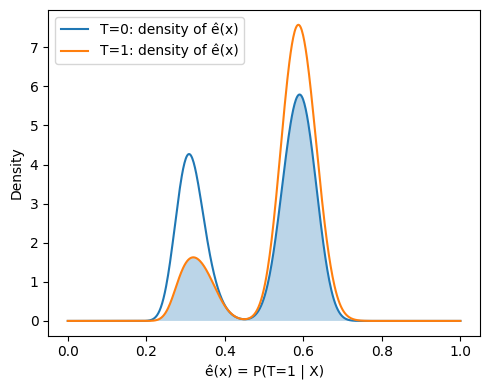

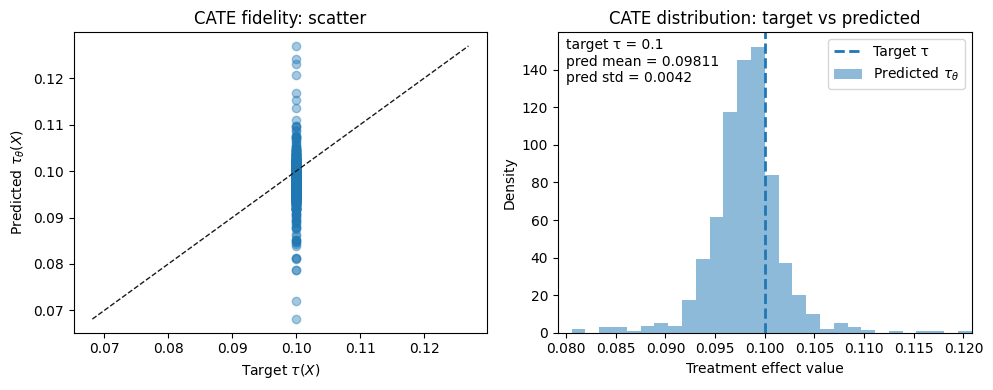

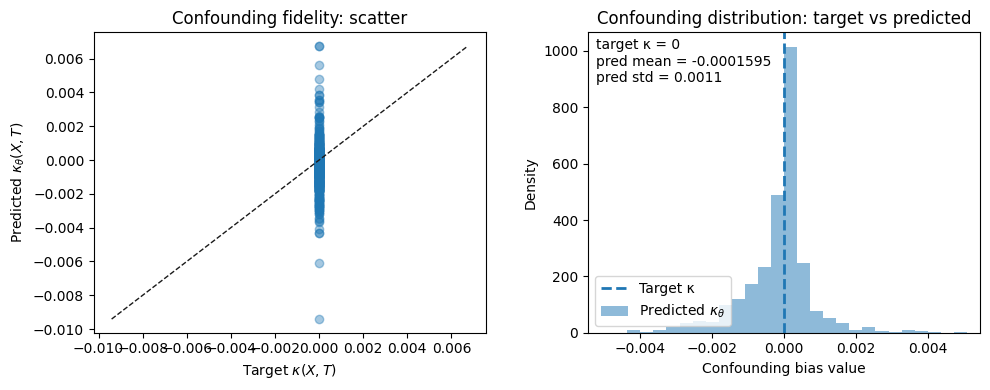

In [0]:
# generate new samples with BGMM and return causal evaluation metrics
out_bgmm = m.causal_bgmm(
    n_samples=1000,
    deterministic=False,
    return_probs=False,
    plot=True,
)

Overlap metrics: {'dec/log_ratio_mean': 0.192, 'dec/log_ratio_std': 0.433, 'dec/target_mean': 0.212, 'dec/target_std': 0.409, 'dec/mse_to_target': 0.007, 'dec/fraction_within_tol': 0.983, 'ps/auc': 0.611, 'ps/hist_overlap_coeff': 0.817, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


/databricks/python/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



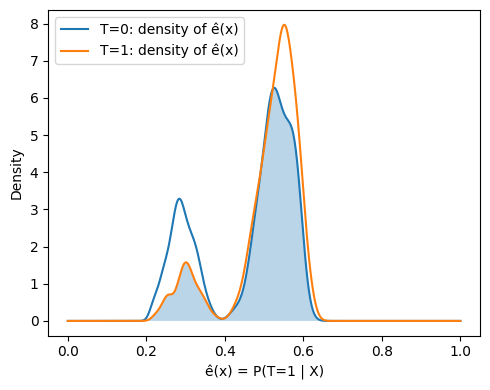

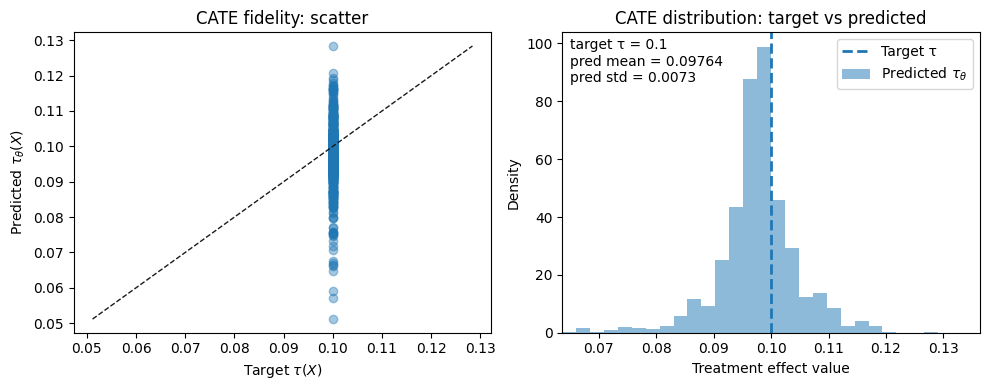

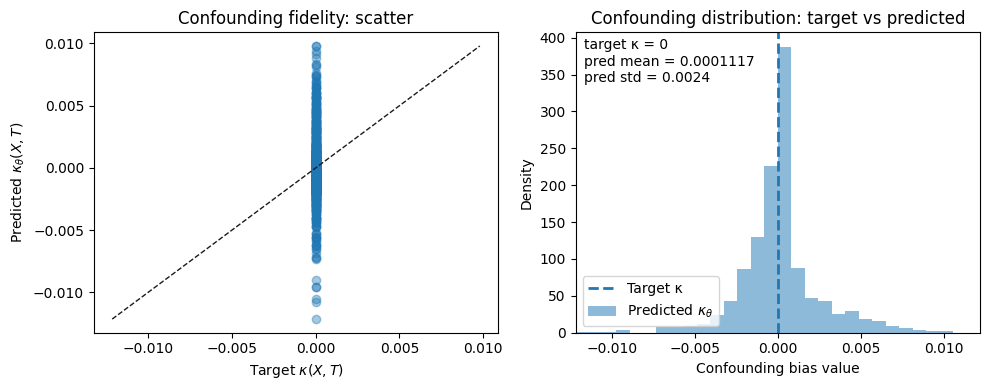

In [0]:
# generate new samples with standard gaussian priors and return causal evaluation metrics
out_gauss = m.causal_gauss(
    n_samples=1000,
    deterministic=False,
    return_probs=False,
    plot=True,
)

In [0]:
# Description of the generated data
# df_gen: postprocessed generated dataset
df_gen = out_bgmm["df_gen"]
print(df_gen.head())
# df_Y: [a realization/sample of the potential outcomes]
df_Y = out_bgmm["df_Y"]
print(df_Y.head())
# df_Ymean [the expected value of the potential outcomes, i.e., probabilities or means]
df_Ymean = out_bgmm["df_Ymean"]
print(df_Ymean.head())
# df_Ymean_prime [the expected potential outcomes given flipped treatment, i.e., E[Y(0)|X, flipped T] and E[Y(1)|X, flipped T]]
df_Ymean_prime = out_bgmm["df_Ymean_prime"] 
print(df_Ymean_prime.head())
# stats: include the following statistics:
stats = out_bgmm["stats"]
#   - inividual treatment effects
print(stats["ite"][:5])
# - average treatment effect
print("ate:",stats["ate"].detach())
# - individual unmeasured confounding bias: T*(y0 - y0') + (1-T)*(y1' - y1)
print(stats["bias"][:5])
# - average unmeasured confounding bias
print("unmeasured confounding bias:", stats["avg_bias"].detach())
# causal evaluation metrics
cm_metrics = out_bgmm["causal_metrics"]
print(cm_metrics)


  X_bin  T  Y X_cat     X_exp  X_uniform    X_beta
0     0  1  1     A  0.090755   1.785639  0.099626
1     0  1  1     A  0.000012  -0.458287  0.448885
2     0  1  1     A  0.274358  -1.804453  0.409382
3     0  1  1     A  0.118422   0.679109  0.361157
4     0  0  1     A  0.428988  -2.059289  0.372569
    Y0   Y1
0  1.0  1.0
1  1.0  1.0
2  1.0  1.0
3  0.0  1.0
4  1.0  1.0
         Y0        Y1
0  0.847390  0.938941
1  0.896970  0.997031
2  0.896226  0.994821
3  0.877152  0.973555
4  0.896556  0.992355
         Y0        Y1
0  0.843847  0.938111
1  0.895597  0.996912
2  0.896288  0.994579
3  0.879244  0.972667
4  0.895926  0.992700
tensor([[0.0916],
        [0.1001],
        [0.0986],
        [0.0964],
        [0.0958]])
ate: tensor([0.0981])
tensor([[ 3.5436e-03],
        [ 1.3736e-03],
        [-6.1572e-05],
        [-2.0918e-03],
        [ 3.4457e-04]])
unmeasured confounding bias: tensor([-0.0002])
CausalEvalResults(mae_tau=0.003, corr_tau=nan, ate_pred=0.098, ate_target=0.1, ate

### Check the details of causal fidelity, distributional fidelity and privacy evaluation

In [0]:
# --------------------------
# 1. Define variable schema
# --------------------------
schema = DataSchema(
    numeric = ["X_exp", "X_uniform", "X_beta"],
    binary = ["X_bin", "T", "Y"],
    categorical = ["X_cat"]
)
# --------------------------
# 2. Initialize evaluator
# --------------------------
evaluator_bgmm = SynthEval(df, df_gen, schema, random_state=13)
# --------------------------
# 3. Run all fidelity metrics
# --------------------------
 # conditional fidelity on treatment groups
dist_bgmm = evaluator_bgmm.run_all(
    conditional_col="T",
    #bins_for_continuous_cond=4,
    #mi_method_mixed="knn",      # default "knn" takes longer time
    mi_method_mixed="discretize", # faster
    include_pairwise_table=True,   # also return a tidy per-pair MI/SU table
)

# --------------------------
# 4. Inspect results
# --------------------------
# 1) Inspect key summaries
print("\n--- Marginal (continuous) ---")
print(dist_bgmm["marginal_continuous"]["aggregates"])

print("\n--- Marginal (discrete) ---")
print(dist_bgmm["marginal_discrete"]["aggregates"])

print("\n--- Pairwise MI (SU-based) ---")
print({k: dist_bgmm["pairwise_mi"][k] for k in ["SU_similarity_mean", "n_pairs"]})

print("\n--- Pairwise discrete (ContingencySimilarity) ---")
print({k: dist_bgmm["pairwise_discrete"][k] for k in ["ContingencySimilarity_mean", "ContingencySimilarity_per_pair", "n_pairs"]})

print("\n--- Conditional fidelity (given treat) ---")
print(dist_bgmm["conditional_mmd2"])

print("\n--- Joint fidelity ---")
print(dist_bgmm["energy"])
print(dist_bgmm["c2st"])

print("\n--- Privacy (DCR baseline protection) ---")
print(dist_bgmm["privacy_dcr"])

# 2) Tidy per-pair MI/SU table
pair_table = dist_bgmm["pairwise_mi"]["table"]
print("\nPer-pair MI/SU (head):")
print(pair_table)
 
# --------------------------
# 5. Interpretation
# --------------------------
# - Low Wasserstein / TV → good marginal fidelity
# - Small correlation/MI difference → preserved dependencies
# - Low Conditional MMD → conditional relationships aligned
# - Low Energy Distance & AUC ≈ 0.5 → strong global fidelity


/local_disk0/.ephemeral_nfs/envs/pythonEnv-f7c8b378-d1fa-4d1a-b374-2bc19c9db985/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-f7c8b378-d1fa-4d1a-b374-2bc19c9db985/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-f7c8b378-d1fa-4d1a-b374-2


--- Marginal (continuous) ---
{'mean_norm_wasserstein': 0.075, 'mean_KSComplement': 0.941}

--- Marginal (discrete) ---
{'mean_TVComplement': 0.956}

--- Pairwise MI (SU-based) ---
{'SU_similarity_mean': 0.981, 'n_pairs': 21}

--- Pairwise discrete (ContingencySimilarity) ---
{'ContingencySimilarity_mean': 0.865, 'ContingencySimilarity_per_pair': {('X_bin', 'T'): 0.87, ('X_bin', 'Y'): 0.69, ('X_bin', 'X_cat'): 0.889, ('T', 'Y'): 0.978, ('T', 'X_cat'): 0.953, ('Y', 'X_cat'): 0.809}, 'n_pairs': 6}

--- Conditional fidelity (given treat) ---
{'per_stratum_mmd2': {'0': -0.002, '1': 0.017}, 'weighted_mean_mmd2': 0.008, 'normalized_ratio_vs_real': -5.775, 'baseline_ref': -0.001}

--- Joint fidelity ---
{'energy_distance': 0.017, 'normalized_energy': 0.006}
{'auc': 0.551, 'n_test': 600, 'auc_complement': 0.898}

--- Privacy (DCR baseline protection) ---
{'protection_fraction': 0.588, 'rr_zero_fraction': 0.0, 'ratio_mean': 1.514, 'ratio_p5': 0.347, 'ratio_p50': 1.148, 'ratio_p95': 3.658, 'sdm

### Comparing Bayesian Gaussian Mixture priors and standard Gaussian priors 

In [0]:
# evaluation using SynthEval plotting functions (for two synthetic datasets from BGMM and standard gaussian)
schema = DataSchema(
    numeric = ["X_exp", "X_uniform", "X_beta"],
    binary = ["X_bin", "T", "Y"],
    categorical = ["X_cat"]
)

evaluator_bgmm = SynthEval(df, out_bgmm["df_gen"], schema)
dist_bgmm = evaluator_bgmm.run_all(conditional_col = "T")

evaluator_gauss = SynthEval(df, out_gauss["df_gen"], schema)
dist_gauss = evaluator_gauss.run_all(conditional_col = "T")

dist_all = {
    "BGMM": dist_bgmm,
    "Gaussian": dist_gauss
}
t_dist = build_table_distributional_fidelity(dist_all)
t_privacy = build_table_privacy(dist_all)

causal_all = {
    "BGMM": out_bgmm,
    "Gaussian": out_gauss
}
t_causal = build_table_causal_structure(causal_all)


print(t_causal)
print(t_dist)
print(t_privacy)


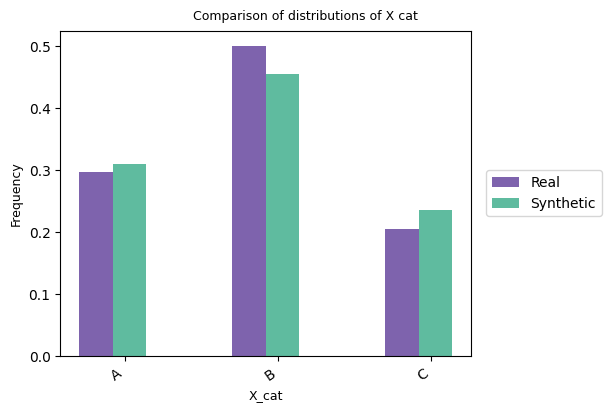

In [0]:
# plot using the evaluator's functions: plot_column(), plot_column_pair(), plot_joint_embedding()
plot = evaluator_bgmm.plot_column("X_cat", main_title = "Comparison of distributions of X cat")

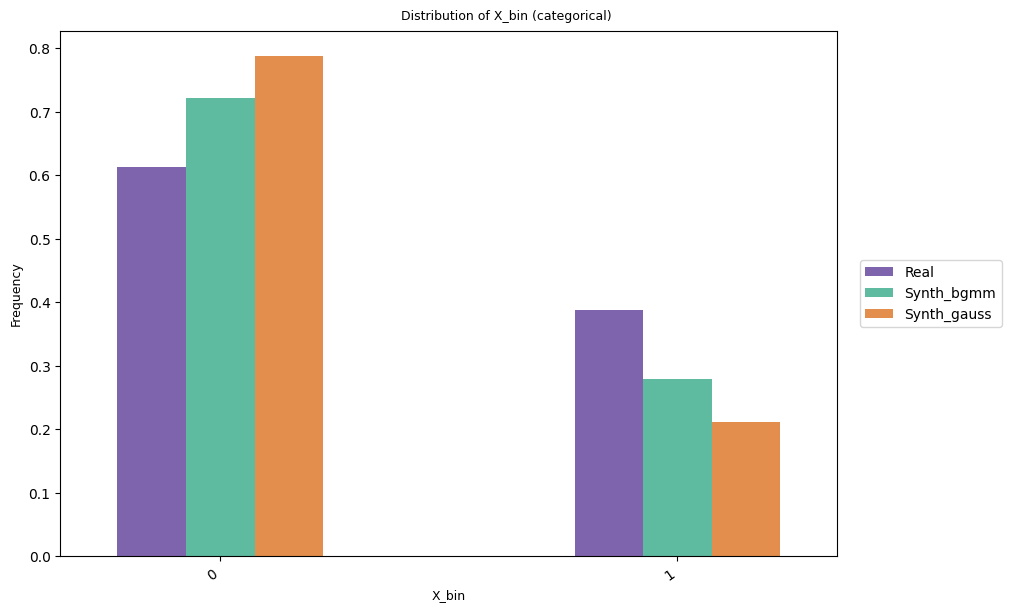

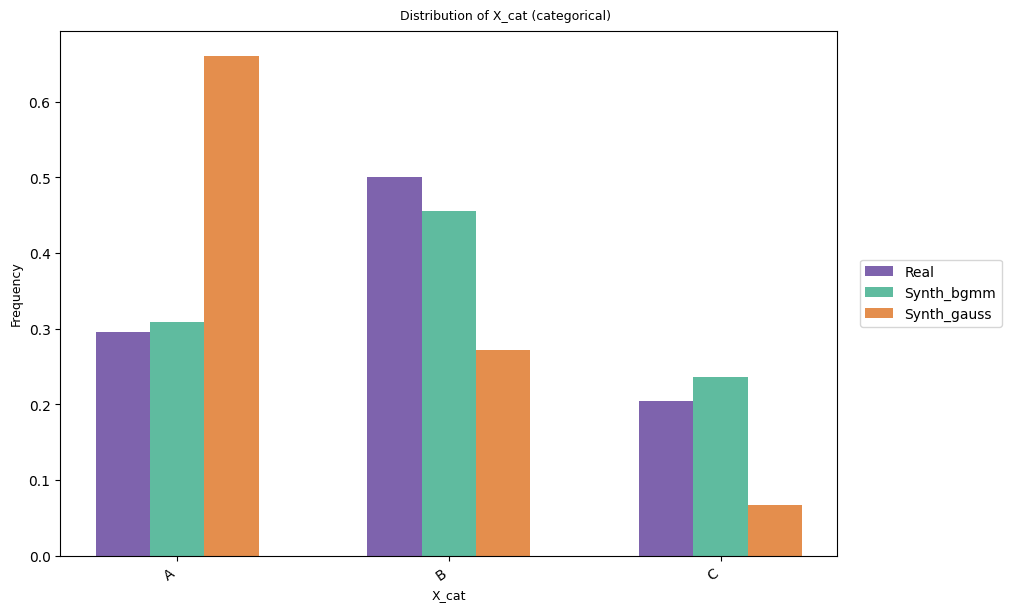

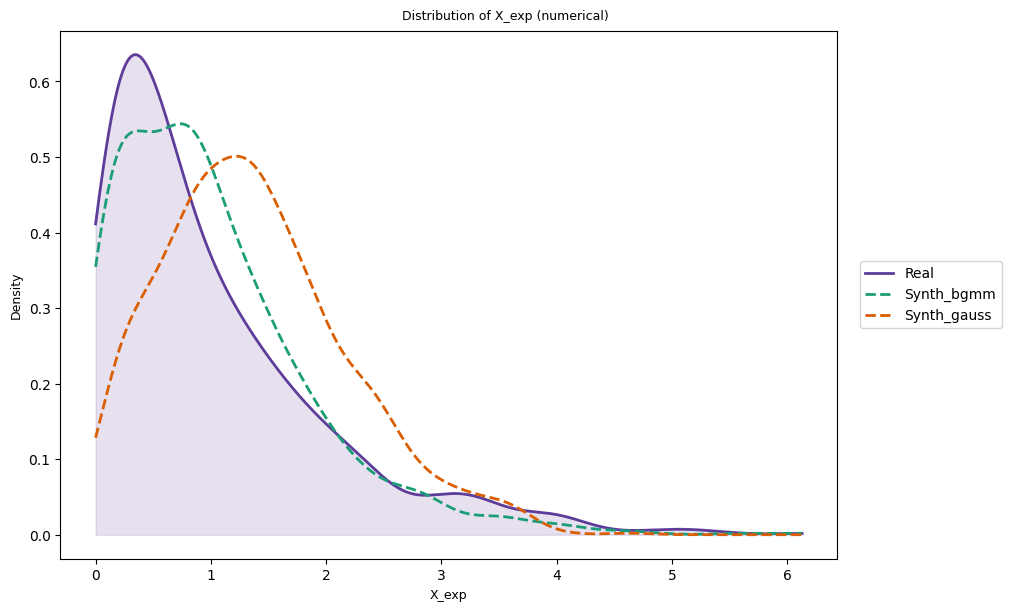

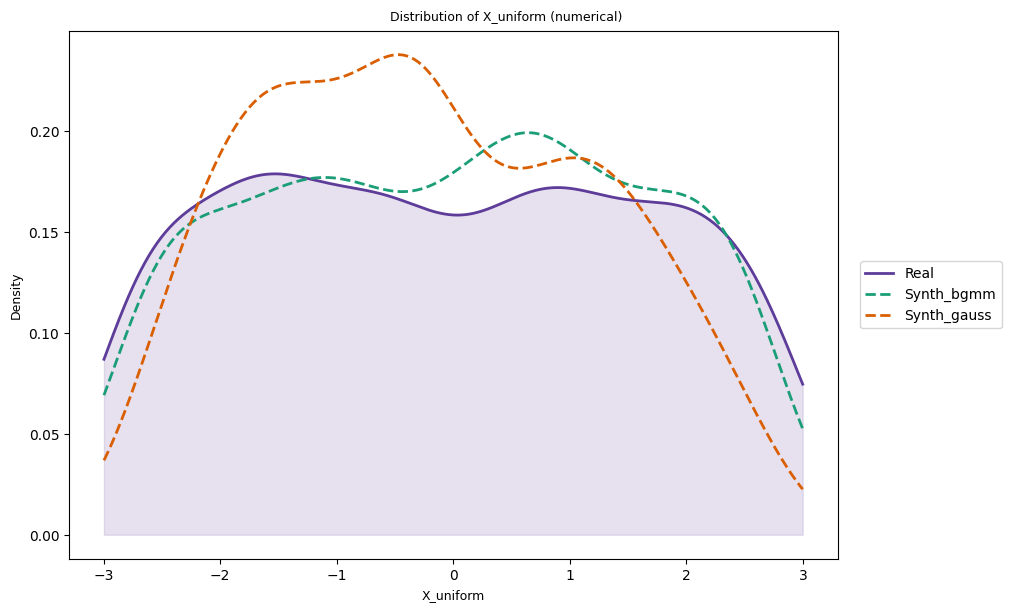

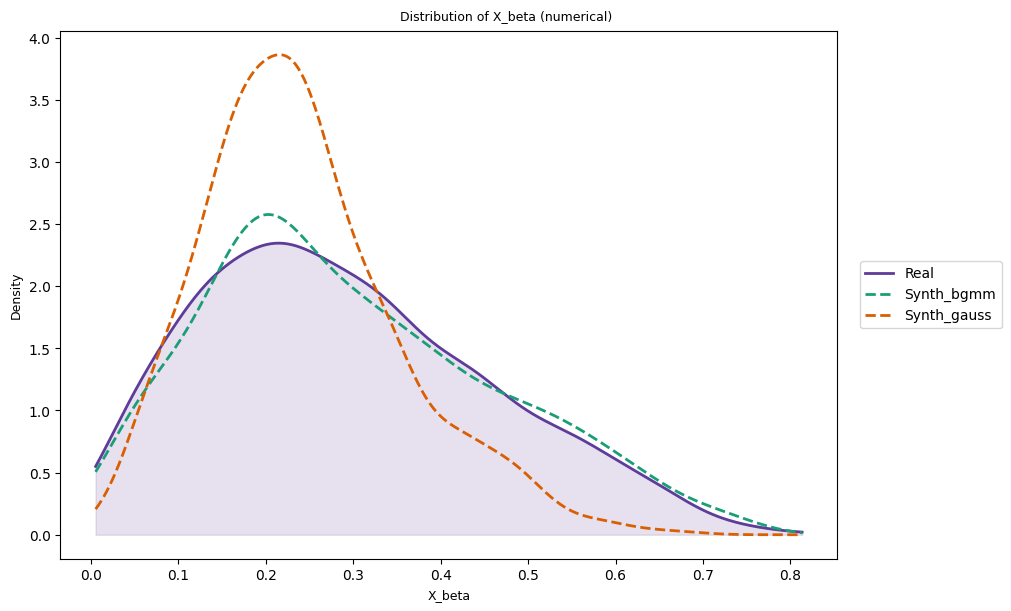

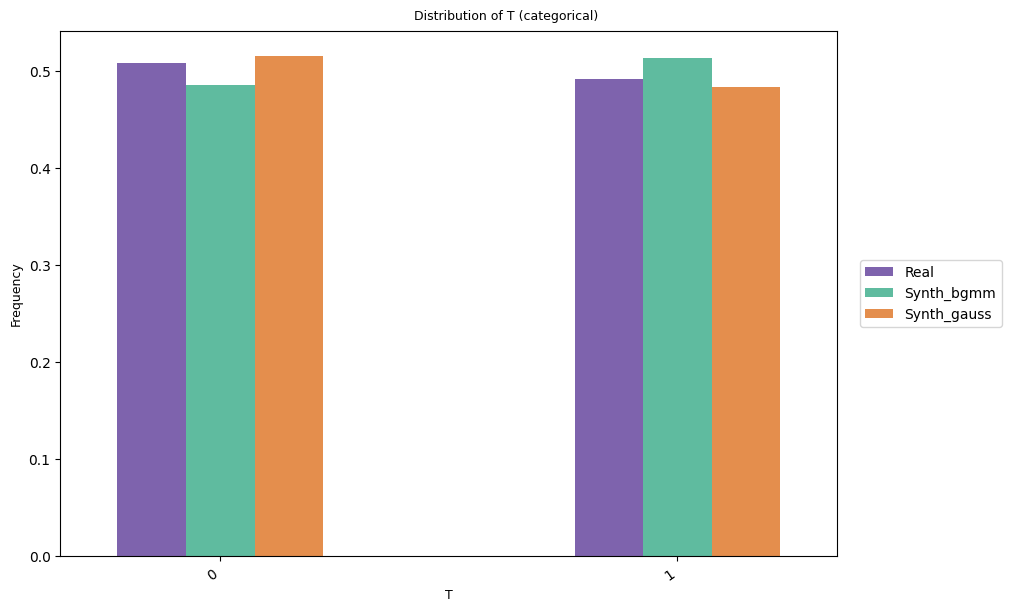

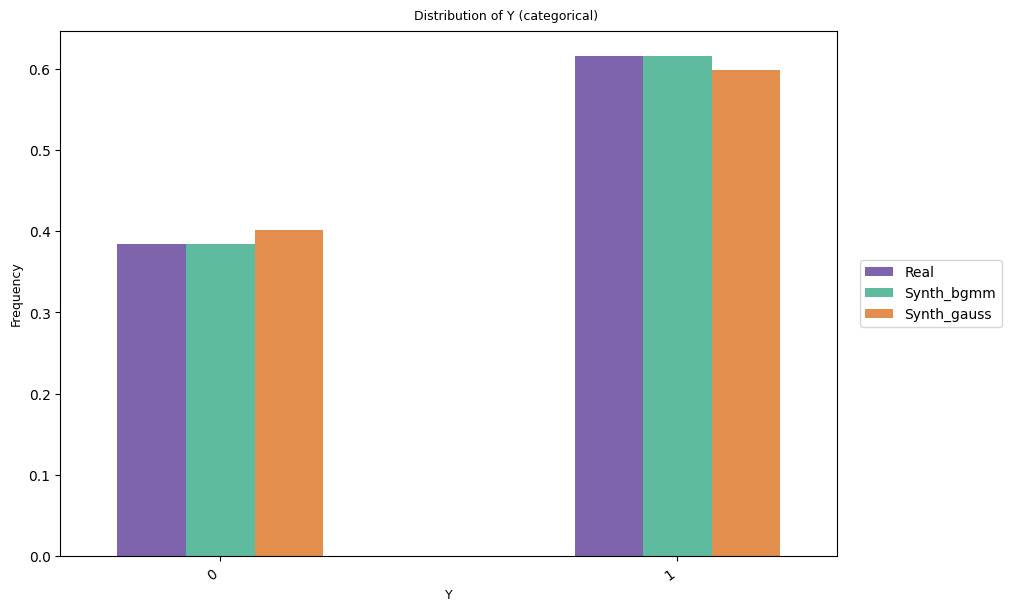

In [0]:
# Alternatively, use the plot functions from the plots module directly
synth_dict = {
    "Synth_bgmm": out_bgmm["df_gen"],
    "Synth_gauss": out_gauss["df_gen"]
}
# single column plots
for var in df.columns:
    fig = single_column_plot(
        real_data=df,
        synthetic_data=synth_dict,
        schema=schema,
        column_name=var,
        x_label=var,
        y_label=None,
        fig_size=(10,6),
        legend_outside=True,
        #show_hist = True,
    )
    fig.show()

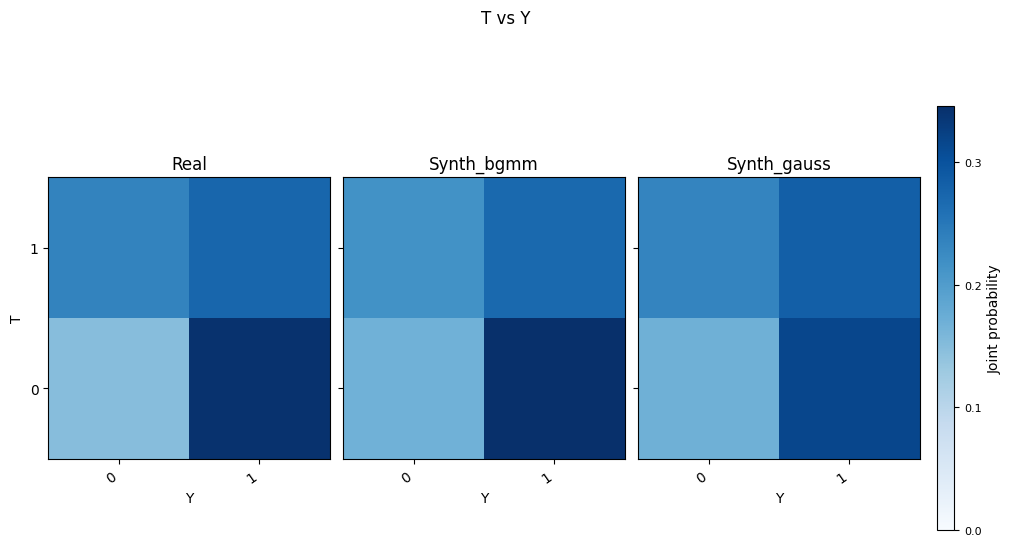

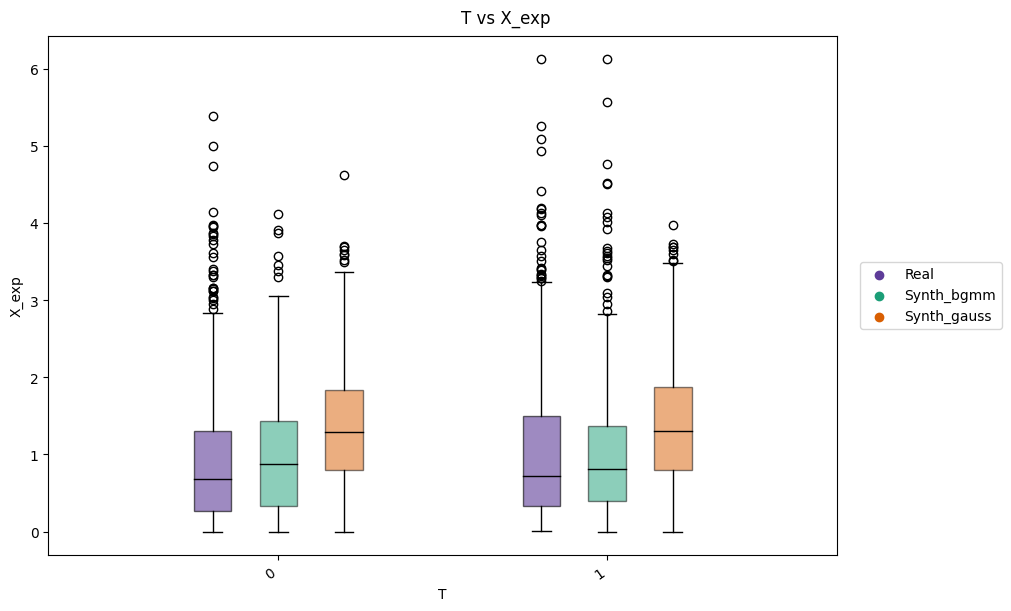

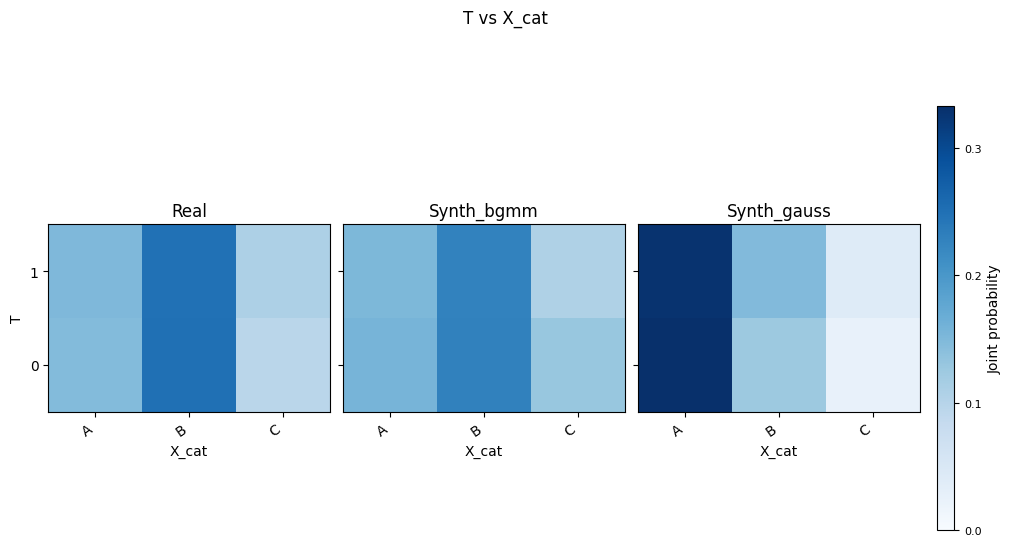

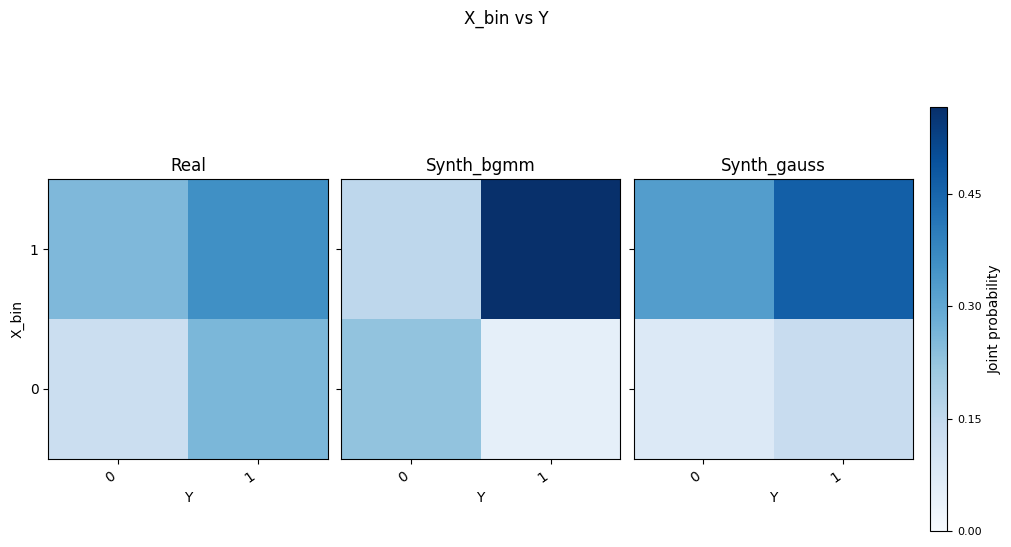

In [0]:
# pair column plots
column_names = [["T", "Y"], ["T", "X_exp"],  ["T", "X_cat"], ["X_bin", "Y"]]
for pair in column_names:
    fig = pair_column_plot(
        real_data=df,
        synthetic_data=synth_dict,
        schema=schema,
        column_names=pair,
        x_label=None,
        y_label=None,
        fig_size=(10,6),
        legend_outside=True,
        #show_hist = True,
    )
    fig.show()

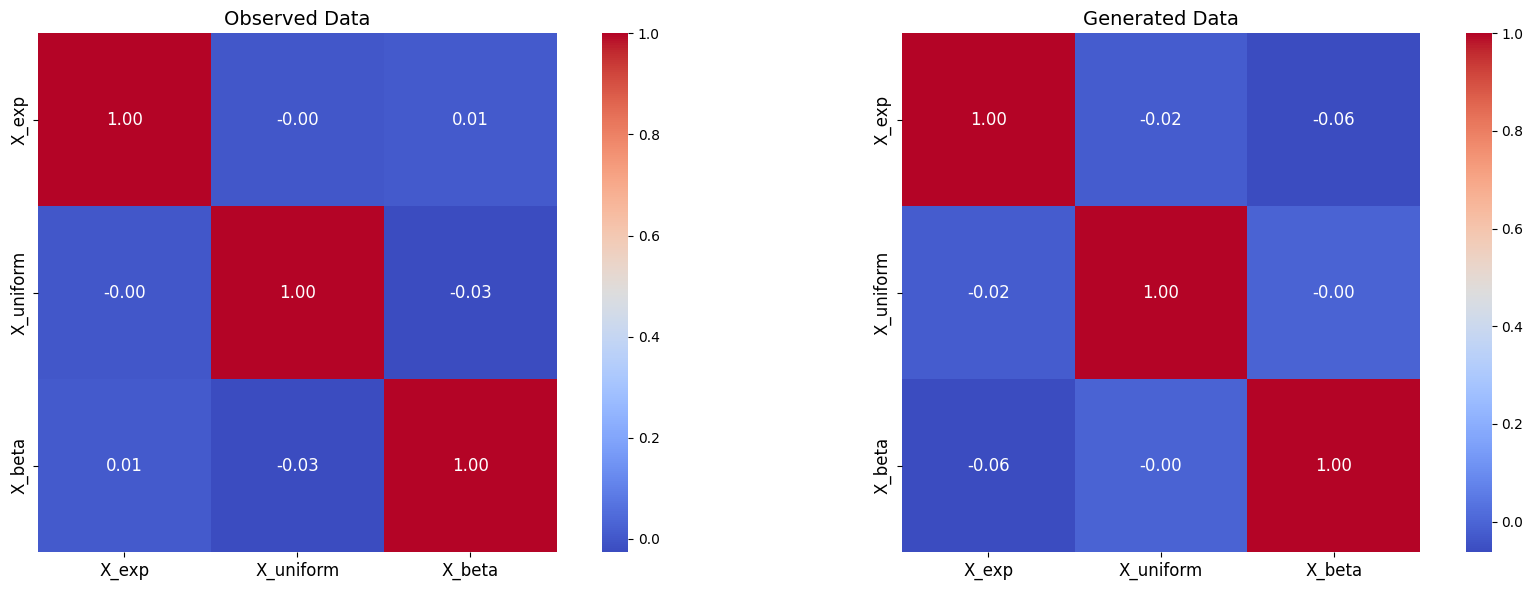

In [0]:
# check correlation between continuous generated X and original X
import seaborn as sns
import matplotlib.pyplot as plt

# Plot side by side with local styling (no global settings)
fig, ax = plt.subplots(ncols=2, figsize=(18, 6))

numerical_var = ["X_exp", "X_uniform", "X_beta"]

# Observed data correlation
sns.heatmap(df[numerical_var].corr(), ax=ax[0], square=True, annot=True, 
            fmt=".2f", cmap="coolwarm", annot_kws={"size": 12})
ax[0].set_title("Observed Data", fontsize=14)
ax[0].tick_params(labelsize=12)
ax[0].grid(False)

# Generated data correlation
sns.heatmap(df_gen[numerical_var].corr(), ax=ax[1], square=True, annot=True, 
            fmt=".2f", cmap="coolwarm", annot_kws={"size": 12})
ax[1].set_title("Generated Data", fontsize=14)
ax[1].tick_params(labelsize=12)
ax[1].grid(False)

plt.tight_layout()
plt.show()